
Final Results Table:

     Model       Alpha         MAE        RMSE        R2
0    Ridge    0.001000    7.080435    8.878587  0.997264
1    Lasso    0.001000    7.080154    8.878589  0.997264
2    Ridge    0.001833    7.080451    8.878588  0.997264
3    Lasso    0.001833    7.079898    8.878594  0.997264
4    Ridge    0.003360    7.080482    8.878590  0.997264
5    Lasso    0.003360    7.079389    8.878610  0.997264
6    Ridge    0.006158    7.080538    8.878596  0.997264
7    Lasso    0.006158    7.078858    8.878662  0.997264
8    Ridge    0.011288    7.080641    8.878615  0.997264
9    Lasso    0.011288    7.077510    8.878846  0.997263
10   Ridge    0.020691    7.080830    8.878682  0.997264
11   Lasso    0.020691    7.076515    8.879422  0.997263
12   Ridge    0.037927    7.081177    8.878907  0.997263
13   Lasso    0.037927    7.074675    8.881329  0.997262
14   Ridge    0.069519    7.081810    8.879661  0.997263
15   Lasso    0.069519    7.071941    8.887262  0.997258
16   Rid

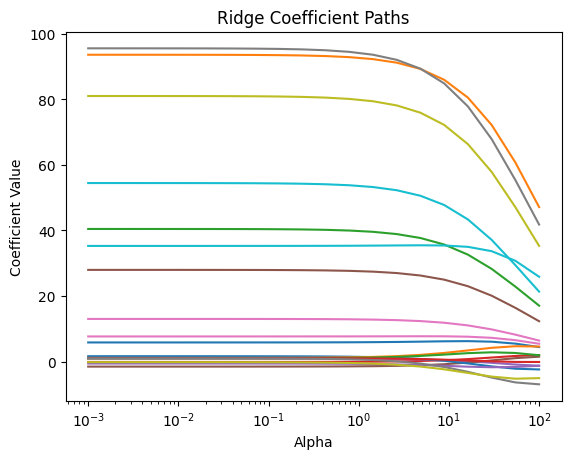

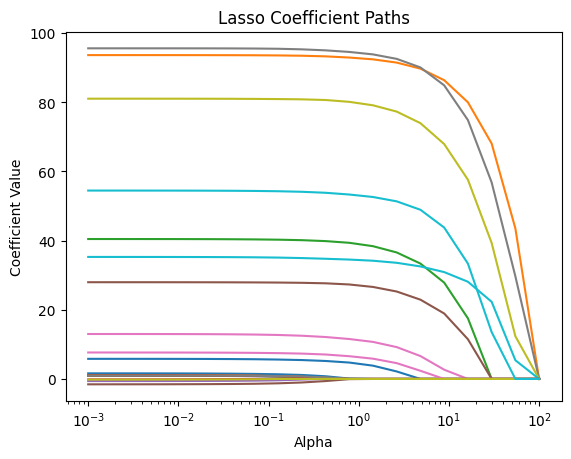


Best Alpha (LassoCV): 0.5177972688024088
Eliminated Features: 4

Model saved as lasso_model.pkl


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# STEP 1: DATASET (AUTO)
# ==============================
X, y = make_regression(n_samples=100, n_features=20, noise=10, random_state=42)

# ==============================
# STEP 2: ALPHA VALUES
# ==============================
alphas = np.logspace(-3, 2, 20)

results = []
ridge_coefs = []
lasso_coefs = []

# ==============================
# STEP 3: TRAIN MODELS
# ==============================
for alpha in alphas:

    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    y_pred_ridge = ridge.predict(X)

    ridge_coefs.append(ridge.coef_)

    mae = mean_absolute_error(y, y_pred_ridge)
    rmse = np.sqrt(mean_squared_error(y, y_pred_ridge))
    r2 = r2_score(y, y_pred_ridge)

    results.append(["Ridge", alpha, mae, rmse, r2])

    # Lasso
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    y_pred_lasso = lasso.predict(X)

    lasso_coefs.append(lasso.coef_)

    mae = mean_absolute_error(y, y_pred_lasso)
    rmse = np.sqrt(mean_squared_error(y, y_pred_lasso))
    r2 = r2_score(y, y_pred_lasso)

    results.append(["Lasso", alpha, mae, rmse, r2])

# ==============================
# STEP 4: LINEAR REGRESSION
# ==============================
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

mae = mean_absolute_error(y, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y, y_pred_lr))
r2 = r2_score(y, y_pred_lr)

results.append(["Linear", 0, mae, rmse, r2])

# ==============================
# STEP 5: RESULTS TABLE
# ==============================
df = pd.DataFrame(results, columns=["Model", "Alpha", "MAE", "RMSE", "R2"])
print("\nFinal Results Table:\n")
print(df)

# ==============================
# STEP 6: COEFFICIENT PLOTS
# ==============================
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

plt.figure()
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i])
plt.xscale("log")
plt.title("Ridge Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.show()

plt.figure()
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i])
plt.xscale("log")
plt.title("Lasso Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.show()

# ==============================
# STEP 7: LASSO CV (BEST MODEL)
# ==============================
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X, y)

print("\nBest Alpha (LassoCV):", lasso_cv.alpha_)

# eliminated features
zero_features = np.sum(lasso_cv.coef_ == 0)
print("Eliminated Features:", zero_features)

# ==============================
# STEP 8: SAVE MODEL (.pkl)
# ==============================
with open("lasso_model.pkl", "wb") as f:
    pickle.dump(lasso_cv, f)

print("\nModel saved as lasso_model.pkl")

In [3]:
from google.colab import files
files.download("lasso_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>